In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import skfuzzy as fuzz

LOCAL_FOLDER = Path.cwd().parent.parent / "local_folder"

df_a = pd.read_csv(LOCAL_FOLDER / 'scored_27_rules.csv')
df_w = pd.read_csv(LOCAL_FOLDER / 'scored_company_data_NEW_RULES.csv')

In [ ]:
from skfuzzy import control as ctrl

STEP = 0.1
Target_Score_A_Array = np.arange(min(df_a['TARGET_SCORE']), max(df_a['TARGET_SCORE']), STEP)
TSA = ctrl.Antecedent(Target_Score_A_Array, 'TSA')
# print(min(df_a['TARGET_SCORE']), max(df_a['TARGET_SCORE']))

Target_Score_W_Array = np.arange(min(df_w['TARGET_SCORE']), max(df_w['TARGET_SCORE']), STEP)
TSW = ctrl.Antecedent(Target_Score_W_Array, 'TSW')
# print(min(df_w['TARGET_SCORE']), max(df_w['TARGET_SCORE']))

TARGET_SCORE = ctrl.Consequent(np.arange(0, 101, 0.1), 'TARGET_SCORE')

In [ ]:
LOW_QUANTILE = 0.25
MID_QUANTILE = 0.5
HIGH_QUANTILE = 0.75

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


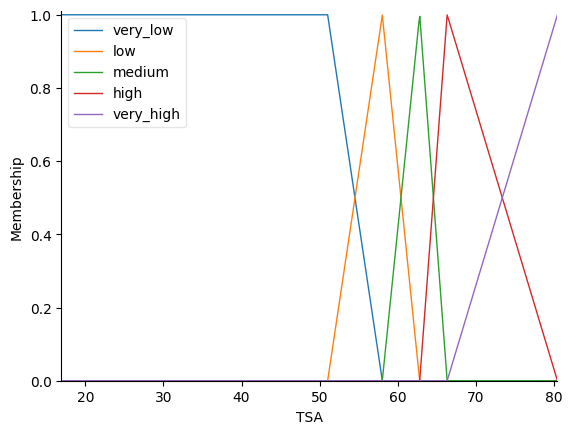

In [ ]:
q_min = min(df_a['TARGET_SCORE'])
q_20 = df_a['TARGET_SCORE'].quantile(0.20)
q_40 = df_a['TARGET_SCORE'].quantile(0.40)
q_60 = df_a['TARGET_SCORE'].quantile(0.60)
q_80 = df_a['TARGET_SCORE'].quantile(0.80)
q_max = max(df_a['TARGET_SCORE'])

universe_tsa = TSA.universe

TSA['very_low'] = fuzz.trapmf(universe_tsa, [q_min, q_min, q_20, q_40])
TSA['low'] = fuzz.trimf(universe_tsa, [q_20, q_40, q_60])
TSA['medium'] = fuzz.trimf(universe_tsa, [q_40, q_60, q_80])
TSA['high'] = fuzz.trimf(universe_tsa, [q_60, q_80, q_max])
TSA['very_high'] = fuzz.trapmf(universe_tsa, [q_80, q_max, q_max, q_max])

TSA.view()

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


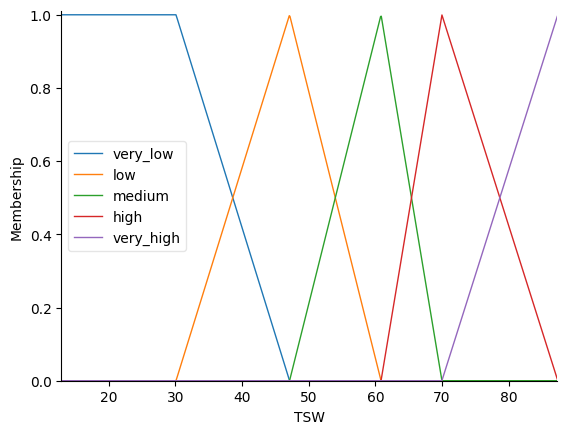

In [ ]:
q_min = min(df_w['TARGET_SCORE'])
q_20 = df_w['TARGET_SCORE'].quantile(0.20)
q_40 = df_w['TARGET_SCORE'].quantile(0.40)
q_60 = df_w['TARGET_SCORE'].quantile(0.60)
q_80 = df_w['TARGET_SCORE'].quantile(0.80)
q_max = max(df_w['TARGET_SCORE'])

universe_tsw = TSW.universe

TSW['very_low'] = fuzz.trapmf(universe_tsw, [q_min, q_min, q_20, q_40])
TSW['low'] = fuzz.trimf(universe_tsw, [q_20, q_40, q_60])
TSW['medium'] = fuzz.trimf(universe_tsw, [q_40, q_60, q_80])
TSW['high'] = fuzz.trimf(universe_tsw, [q_60, q_80, q_max])
TSW['very_high'] = fuzz.trapmf(universe_tsw, [q_80, q_max, q_max, q_max])

TSW.view()

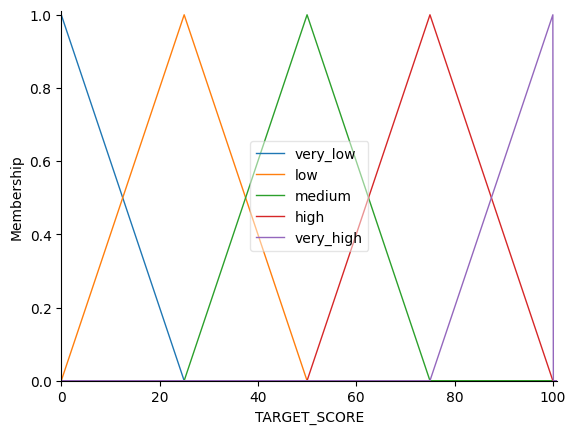

In [ ]:
universe_target = TARGET_SCORE.universe

TARGET_SCORE['very_low'] = fuzz.trimf(universe_target, [0, 0, 25])
TARGET_SCORE['low'] = fuzz.trimf(universe_target, [0, 25, 50])
TARGET_SCORE['medium'] = fuzz.trimf(universe_target, [25, 50, 75])
TARGET_SCORE['high'] = fuzz.trimf(universe_target, [50, 75, 100])
TARGET_SCORE['very_high'] = fuzz.trimf(universe_target, [75, 100, 100])

TARGET_SCORE.view()

- very_low = 0 pkt
- low = 3 pkt
- medium = 6 pkt
- high = 9 pkt
- very_high = 12 pkt

a) Suma 0 – 3 pkt: very_low

b) Suma 6 – 9 pkt: low

c) Suma 12 pkt: medium

d) Suma 15 – 18 pkt: high

e) Suma 21 – 24 pkt: very_high

In [ ]:
# ==========================================
# GRUPA 1: TSW na poziomie VERY_LOW (0 pkt)
# ==========================================
rule1 = ctrl.Rule(TSW['very_low'] & TSA['very_low'], TARGET_SCORE['very_low'])   # 0+0 = 0
rule2 = ctrl.Rule(TSW['very_low'] & TSA['low'], TARGET_SCORE['very_low'])        # 0+3 = 3
rule3 = ctrl.Rule(TSW['very_low'] & TSA['medium'], TARGET_SCORE['low'])          # 0+6 = 6
rule4 = ctrl.Rule(TSW['very_low'] & TSA['high'], TARGET_SCORE['low'])            # 0+9 = 9
rule5 = ctrl.Rule(TSW['very_low'] & TSA['very_high'], TARGET_SCORE['medium'])    # 0+12 = 12

# ==========================================
# GRUPA 2: TSW na poziomie LOW (3 pkt)
# ==========================================
rule6 = ctrl.Rule(TSW['low'] & TSA['very_low'], TARGET_SCORE['very_low'])        # 3+0 = 3
rule7 = ctrl.Rule(TSW['low'] & TSA['low'], TARGET_SCORE['low'])                  # 3+3 = 6
rule8 = ctrl.Rule(TSW['low'] & TSA['medium'], TARGET_SCORE['low'])               # 3+6 = 9
rule9 = ctrl.Rule(TSW['low'] & TSA['high'], TARGET_SCORE['medium'])              # 3+9 = 12
rule10 = ctrl.Rule(TSW['low'] & TSA['very_high'], TARGET_SCORE['high'])          # 3+12 = 15

# ==========================================
# GRUPA 3: TSW na poziomie MEDIUM (6 pkt)
# ==========================================
rule11 = ctrl.Rule(TSW['medium'] & TSA['very_low'], TARGET_SCORE['low'])         # 6+0 = 6
rule12 = ctrl.Rule(TSW['medium'] & TSA['low'], TARGET_SCORE['low'])              # 6+3 = 9
rule13 = ctrl.Rule(TSW['medium'] & TSA['medium'], TARGET_SCORE['medium'])        # 6+6 = 12
rule14 = ctrl.Rule(TSW['medium'] & TSA['high'], TARGET_SCORE['high'])            # 6+9 = 15
rule15 = ctrl.Rule(TSW['medium'] & TSA['very_high'], TARGET_SCORE['high'])       # 6+12 = 18

# ==========================================
# GRUPA 4: TSW na poziomie HIGH (9 pkt)
# ==========================================
rule16 = ctrl.Rule(TSW['high'] & TSA['very_low'], TARGET_SCORE['low'])           # 9+0 = 9
rule17 = ctrl.Rule(TSW['high'] & TSA['low'], TARGET_SCORE['medium'])             # 9+3 = 12
rule18 = ctrl.Rule(TSW['high'] & TSA['medium'], TARGET_SCORE['high'])            # 9+6 = 15
rule19 = ctrl.Rule(TSW['high'] & TSA['high'], TARGET_SCORE['high'])              # 9+9 = 18
rule20 = ctrl.Rule(TSW['high'] & TSA['very_high'], TARGET_SCORE['very_high'])    # 9+12 = 21

# ==========================================
# GRUPA 5: TSW na poziomie VERY_HIGH (12 pkt)
# ==========================================
rule21 = ctrl.Rule(TSW['very_high'] & TSA['very_low'], TARGET_SCORE['medium'])   # 12+0 = 12
rule22 = ctrl.Rule(TSW['very_high'] & TSA['low'], TARGET_SCORE['high'])          # 12+3 = 15
rule23 = ctrl.Rule(TSW['very_high'] & TSA['medium'], TARGET_SCORE['high'])       # 12+6 = 18
rule24 = ctrl.Rule(TSW['very_high'] & TSA['high'], TARGET_SCORE['very_high'])    # 12+9 = 21
rule25 = ctrl.Rule(TSW['very_high'] & TSA['very_high'], TARGET_SCORE['very_high']) # 12+12 = 24

rules = [
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
    rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20,
    rule21, rule22, rule23, rule24, rule25
]

In [ ]:
meta_ctrl = ctrl.ControlSystem(rules)
meta_sim = ctrl.ControlSystemSimulation(meta_ctrl)

df_merged = pd.merge(
    df_a[['CompanyID', 'TARGET_SCORE']], 
    df_w[['CompanyID', 'TARGET_SCORE']], 
    on='CompanyID', 
    suffixes=('_A', '_W')
)

final_scores = []

for index, row in df_merged.iterrows():

    meta_sim.input['TSA'] = row['TARGET_SCORE_A']
    meta_sim.input['TSW'] = row['TARGET_SCORE_W']
    
    meta_sim.compute()
    
    final_scores.append(meta_sim.output['TARGET_SCORE'])
    print(f"[{index + 1}/{len(df_merged)} companies] ")

df_merged['FINAL_CASCADE_SCORE'] = final_scores

output_filename = LOCAL_FOLDER / 'scored_company_data_HFS.csv'
df_merged.to_csv(output_filename, index=False)

print("-" * 50)
print(f"Sukces! Symulacja zakończona dla {len(df_merged)} firm.")
print(f"Wyniki zostały zapisane do pliku: {output_filename}")

df_merged_sorted = df_merged.sort_values(by='FINAL_CASCADE_SCORE', ascending=False)
display(df_merged_sorted.head(10))

[1/1000 companies] 
[2/1000 companies] 
[3/1000 companies] 
[4/1000 companies] 
[5/1000 companies] 
[6/1000 companies] 
[7/1000 companies] 
[8/1000 companies] 
[9/1000 companies] 
[10/1000 companies] 
[11/1000 companies] 
[12/1000 companies] 
[13/1000 companies] 
[14/1000 companies] 
[15/1000 companies] 
[16/1000 companies] 
[17/1000 companies] 
[18/1000 companies] 
[19/1000 companies] 
[20/1000 companies] 
[21/1000 companies] 
[22/1000 companies] 
[23/1000 companies] 
[24/1000 companies] 
[25/1000 companies] 
[26/1000 companies] 
[27/1000 companies] 
[28/1000 companies] 
[29/1000 companies] 
[30/1000 companies] 
[31/1000 companies] 
[32/1000 companies] 
[33/1000 companies] 
[34/1000 companies] 
[35/1000 companies] 
[36/1000 companies] 
[37/1000 companies] 
[38/1000 companies] 
[39/1000 companies] 
[40/1000 companies] 
[41/1000 companies] 
[42/1000 companies] 
[43/1000 companies] 
[44/1000 companies] 
[45/1000 companies] 
[46/1000 companies] 
[47/1000 companies] 
[48/1000 companies] 
[

,CompanyID,TARGET_SCORE_A,TARGET_SCORE_W,FINAL_CASCADE_SCORE
466,467,80.43,71.39,91.566251
170,171,67.68,87.30,91.363467
256,257,70.30,87.36,90.903693
917,918,80.44,75.99,90.870157
68,69,80.21,69.97,90.786218
433,434,80.21,71.08,90.754157
61,62,80.19,69.97,90.709790
257,258,80.21,72.90,90.567654
863,864,80.15,70.25,90.558453
808,809,70.74,87.17,90.410760
